<a href="https://colab.research.google.com/github/gunwes16/data201-project1-classification/blob/main/analysis/notebooks/4.0-model-evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/gunwes16/data201-project1-classification/refs/heads/main/data/processed/bank-clean%20(2).csv"
df = pd.read_csv(url)   # creates df; every later cell depends on it
print(df.shape)         # expect (45211, 17)

(45211, 17)


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

# Same split as 3.0 (same random_state, so the same test set)
y = df["y"]
X = df.drop(columns="y")
cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

def make_model(clf):
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                              sparse_output=False), cat_cols)])
    return Pipeline([("prep", prep), ("clf", clf)])

print(X_train.shape, X_test.shape)   # expect (36168, 16) (9043, 16)

(36168, 16) (9043, 16)


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),   # use the K you chose in 3.0
}
thresholds = np.arange(0.05, 0.95, 0.05)   # try cutoffs 0.05, 0.10, ... 0.90

rows = []
for name, clf in models.items():
    # Out-of-fold probabilities: each client is scored by a model that never saw them
    proba = cross_val_predict(make_model(clf), X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]
    f1s = [f1_score(y_train, (proba >= t).astype(int)) for t in thresholds]
    best_i = int(np.argmax(f1s))
    rows.append({"model": name,
                 "F1 at 0.5": round(f1_score(y_train, (proba >= 0.5).astype(int)), 3),
                 "best threshold": round(thresholds[best_i], 2),
                 "F1 at best": round(f1s[best_i], 3)})

tuned = pd.DataFrame(rows).sort_values("F1 at best", ascending=False)
tuned

,model,F1 at 0.5,best threshold,F1 at best
0,Logistic,0.274,0.20,0.439
1,LDA,0.365,0.15,0.438
2,QDA,0.366,0.20,0.410
3,KNN (k=5),0.284,0.25,0.379


In [6]:
winner = tuned.iloc[0]["model"]
best_t = tuned.iloc[0]["best threshold"]
print(f"Winner: {winner} at threshold {best_t}")

final_model = make_model(models[winner]).fit(X_train, y_train)   # refit on all training data
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Accuracy    {(tp + tn) / cm.sum():.3f}")
print(f"Precision   {tp / (tp + fp):.3f}")
print(f"Recall      {tp / (tp + fn):.3f}")
print(f"Specificity {tn / (tn + fp):.3f}")
print(f"F1          {f1_score(y_test, test_pred):.3f}")

Winner: Logistic at threshold 0.2
TN=7445  FP=540  FN=592  TP=466
Accuracy    0.875
Precision   0.463
Recall      0.440
Specificity 0.932
F1          0.452


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

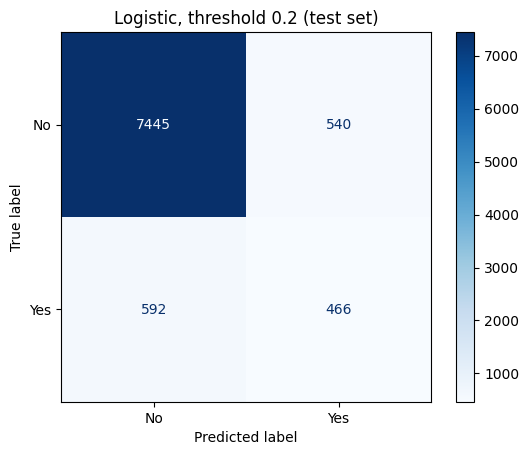

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred,
                                        display_labels=["No", "Yes"], cmap="Blues")
plt.title(f"{winner}, threshold {best_t} (test set)")
plt.savefig("4.1-confusion-matrix.png", dpi=120, bbox_inches="tight")
files.download("4.1-confusion-matrix.png")